In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- 1. Define the Objective Function ---
def cost_function(x, y):
    return x * np.sin(4 * x) + 1.1 * y * np.sin(2 * y)

In [2]:
# --- 2. GA Implementation ---

# Parameters
POP_SIZE = 100
GENERATIONS = 50
MUTATION_RATE = 0.1
BOUNDS = [0, 10]
SIGMA = 0.5 # Standard deviation for Gaussian mutation

# Initialization
def create_population(size):
    # Create random individuals within bounds
    return np.random.uniform(BOUNDS[0], BOUNDS[1], (size, 2))

# Evaluation
def evaluate(population):
    # Calculate cost for all particles
    return np.array([cost_function(ind[0], ind[1]) for ind in population])

# Tournament Selection
def selection(population, scores, k=3):
    selected = []
    for _ in range(len(population)):
        # Pick k random indices
        idx = np.random.randint(0, len(population), k)
        # Choose the one with the lowest score (minimization)
        best_candidate_idx = idx[np.argmin(scores[idx])]
        selected.append(population[best_candidate_idx])
    return np.array(selected)

# Arithmetic Crossover
def crossover(p1, p2, alpha=0.5):
    # Child is a weighted average of parents
    c1 = alpha * p1 + (1 - alpha) * p2
    c2 = alpha * p2 + (1 - alpha) * p1
    return c1, c2

# Gaussian Mutation
def mutate(ind, mutation_rate, sigma):
    if np.random.rand() < mutation_rate:
        # Add random noise
        noise = np.random.normal(0, sigma, 2)
        ind += noise
        # Ensure bounds are respected
        ind = np.clip(ind, BOUNDS[0], BOUNDS[1])
    return ind

In [ ]:
# --- 3. Run Genetic Algorithm ---

# Initialize
population = create_population(POP_SIZE)
best_history = []
avg_history = []

print(f"Starting Continuous GA with {POP_SIZE} individuals for {GENERATIONS} generations...")

for gen in range(GENERATIONS):
    # Evaluate
    scores = evaluate(population)
    
    # Statistics
    best_score = np.min(scores)
    avg_score = np.mean(scores)
    best_history.append(best_score)
    avg_history.append(avg_score)
    
    # Store global best of this generation
    best_ind_idx = np.argmin(scores)
    best_ind = population[best_ind_idx]
    
    if gen % 10 == 0:
        print(f"Generation {gen:3d} | Best Cost: {best_score:.5f} | Position: [{best_ind[0]:.4f}, {best_ind[1]:.4f}]")
        
    # Selection
    parents = selection(population, scores)
    
    # Reproduction
    next_pop = []
    for i in range(0, POP_SIZE, 2):
        p1 = parents[i]
        p2 = parents[i+1] if i+1 < POP_SIZE else parents[0]
        
        # Crossover
        c1, c2 = crossover(p1, p2)
        
        # Mutation
        c1 = mutate(c1, MUTATION_RATE,                                                                                  +9  )
        c2 = mutate(c2, MUTATION_RATE, SIGMA)
        
        next_pop.extend([c1, c2])
        
    population = np.array(next_pop)[:POP_SIZE]

# Final improvements
final_scores = evaluate(population)
global_best_idx = np.argmin(final_scores)
global_best_ind = population[global_best_idx]
global_best_cost = final_scores[global_best_idx]

print("\nOptimization Complete!")
print("-" * 30)
print(f"Optimal Solution Found:")
print(f"x = {global_best_ind[0]:.6f}")
print(f"y = {global_best_ind[1]:.6f}")
print(f"Minimum Cost = {global_best_cost:.6f}")
print("-" * 30)

Starting Continuous GA with 100 individuals for 50 generations...
Generation   0 | Best Cost: -13.23774 | Position: [9.1955, 5.4378]
Generation  10 | Best Cost: -13.47049 | Position: [7.4404, 5.5790]
Generation  20 | Best Cost: -13.46906 | Position: [7.4358, 5.5376]
Generation  30 | Best Cost: -13.46595 | Position: [7.4349, 5.5393]
Generation  40 | Best Cost: -13.46595 | Position: [7.4349, 5.5393]

Optimization Complete!
------------------------------
Optimal Solution Found:
x = 7.434941
y = 5.539272
Minimum Cost = -13.465945
------------------------------


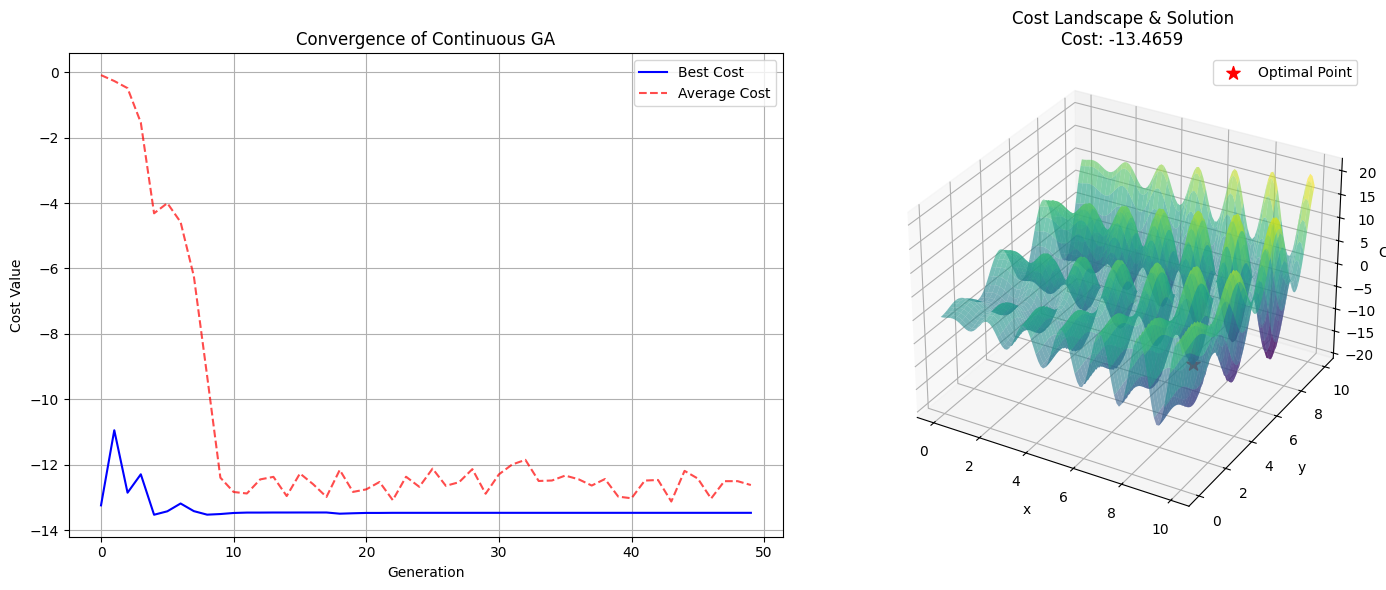

In [4]:
# --- 4. Visualization ---

plt.figure(figsize=(15, 6))

# Plot 1: Convergence
plt.subplot(1, 2, 1)
plt.plot(best_history, 'b-', label='Best Cost')
plt.plot(avg_history, 'r--', alpha=0.7, label='Average Cost')
plt.title('Convergence of Continuous GA')
plt.xlabel('Generation')
plt.ylabel('Cost Value')
plt.legend()
plt.grid(True)

# Plot 2: 3D Landscape with Solution
x_range = np.linspace(0, 10, 100)
y_range = np.linspace(0, 10, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = cost_function(X, Y)

ax = plt.subplot(1, 2, 2, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6, edgecolor='none')
ax.scatter(global_best_ind[0], global_best_ind[1], global_best_cost, color='red', s=100, marker='*', label='Optimal Point')

ax.set_title(f'Cost Landscape & Solution\nCost: {global_best_cost:.4f}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('Cost')
ax.legend()

plt.tight_layout()
plt.show()